### Text Cleaning and Basic Preprocessing

Before we can analyze text data, it needs to be standardized.  
This involves removing unnecessary symbols, punctuation, and converting all letters to lowercase.  
Such preprocessing helps ensure that words like *“Amazing”* and *“amazing”* are treated the same by the model.  

In this example:
- We start with a short movie review sentence.
- Convert it to lowercase.
- Remove all non-letter characters (punctuation, emojis, numbers, etc.) using a regular expression.

#### Understanding Regular Expressions (RegEx) in Text Cleaning

Regular expressions, or **RegEx**, are a powerful way to identify and manipulate patterns in text.  
They are particularly useful in natural language preprocessing for tasks like:
- Removing unwanted symbols, punctuation, or numbers.
- Extracting specific patterns such as hashtags, mentions, or URLs.
- Normalizing text by substituting patterns with cleaner forms.

In this context, the expression  
`r'[^a-zA-Z\s]'`  
means “match anything that is **not** a letter (A–Z or a–z) or a whitespace.”  
Using this inside `re.sub()` replaces all such characters with an empty string — effectively cleaning the text.

In [1]:
import re
sample_text = "The film's acting was AMAZING!!! But... the plot? Not so much 😒"
# Lowercase everything and remove non-letter characters
cleaned_text = re.sub(r'[^a-zA-Z\s]', '', sample_text.lower())
print("Cleaned:", cleaned_text)

Cleaned: the films acting was amazing but the plot not so much 


### Tokenization — Splitting Text into Words

After cleaning, the next essential step in text preprocessing is **tokenization**,  
which means splitting text into smaller units — typically *words* or *tokens*.  
This allows models to process individual words rather than entire sentences as one string.

Here we:
- Use NLTK’s `word_tokenize()` function to split the cleaned text.
- Ensure that the tokenizer resource (`punkt`) is downloaded first.
- Display the resulting list of tokens.

In [2]:
import nltk
from nltk.tokenize import word_tokenize

# Download both required tokenizers (new NLTK versions separate these)
nltk.download('punkt')
nltk.download('punkt_tab')

tokens = word_tokenize(cleaned_text)
print("Tokens:", tokens)

Tokens: ['the', 'films', 'acting', 'was', 'amazing', 'but', 'the', 'plot', 'not', 'so', 'much']


[nltk_data] Downloading package punkt to /root/nltk_data...
[nltk_data]   Package punkt is already up-to-date!
[nltk_data] Downloading package punkt_tab to /root/nltk_data...
[nltk_data]   Package punkt_tab is already up-to-date!


### Removing Stopwords

Many common words such as *“the”*, *“is”*, *“and”*, or *“in”* appear frequently in text but carry very little semantic meaning.  
These are called **stopwords**, and removing them helps models focus on the more meaningful terms in the data.  

Here we:
- Load a predefined list of English stopwords from NLTK.
- Filter out those words from our tokenized text.
- Display the cleaned list of tokens that now contains only informative words.

In [3]:
from nltk.corpus import stopwords
nltk.download('stopwords')
stop_words = set(stopwords.words('english'))

filtered_tokens = [word for word in tokens if word not in stop_words]
print("Without stopwords:", filtered_tokens)

Without stopwords: ['films', 'acting', 'amazing', 'plot', 'much']


[nltk_data] Downloading package stopwords to /root/nltk_data...
[nltk_data]   Package stopwords is already up-to-date!


### Word Stemming — Reducing Words to Their Root Form

**Stemming** is the process of reducing words to their base or root form by trimming suffixes.  
For example, words like *“running”*, *“runs”*, and *“ran”* all reduce to the stem *“run”*.  
This helps treat different grammatical variations of a word as the same feature in analysis.

In this example:
- We use NLTK’s `PorterStemmer`, one of the most common stemming algorithms.
- Each filtered token is stemmed individually.
- The resulting list shows the simplified, stemmed versions of the original words.

In [4]:
from nltk.stem import PorterStemmer

stemmer = PorterStemmer()
stemmed_tokens = [stemmer.stem(word) for word in filtered_tokens]
print("Stemmed:", stemmed_tokens)

Stemmed: ['film', 'act', 'amaz', 'plot', 'much']


### Lemmatization with spaCy

**Lemmatization** is a more advanced alternative to stemming.  
Instead of simply chopping off word endings, it uses linguistic knowledge to return the **dictionary base form** (lemma) of each word.  
For example, *“running”* → *“run”* and *“better”* → *“good”*.

Here we:
- Download and load spaCy’s small English language model (`en_core_web_sm`).
- Process our filtered tokens as a single document.
- Extract and display the **lemmatized tokens**, which are linguistically normalized versions of the words.

In [5]:
import spacy
spacy.cli.download("en_core_web_sm")

# Load the spaCy model
nlp = spacy.load("en_core_web_sm")
doc = nlp(" ".join(filtered_tokens))

lemmatized_tokens = [token.lemma_ for token in doc]
print("Lemmatized:", lemmatized_tokens)

✔ Download and installation successful
You can now load the package via spacy.load('en_core_web_sm')
⚠ Restart to reload dependencies
If you are in a Jupyter or Colab notebook, you may need to restart Python in
order to load all the package's dependencies. You can do this by selecting the
'Restart kernel' or 'Restart runtime' option.
Lemmatized: ['film', 'act', 'amazing', 'plot', 'much']


### Bag of Words (BoW) Representation

The **Bag of Words** model converts text into numerical form by counting how often each word appears in a document.  
It ignores grammar and word order but provides a simple way to represent text for machine learning models.

Here we:
- Define a small set of example movie review sentences as our corpus.
- Use `CountVectorizer` from scikit-learn to build the Bag of Words representation.
- Print the vocabulary (unique words identified) and the resulting matrix of word counts for each sentence.

In [6]:
from sklearn.feature_extraction.text import CountVectorizer

corpus = [
    "I love this movie, it's fantastic!",
    "This movie was awful and boring.",
    "Fantastic visuals but weak storyline.",
    "I wouldn't recommend this film."
]

vectorizer = CountVectorizer()
X_bow = vectorizer.fit_transform(corpus)

print("Vocabulary:", vectorizer.get_feature_names_out())
print("BoW Matrix:\n", X_bow.toarray())

Vocabulary: ['and' 'awful' 'boring' 'but' 'fantastic' 'film' 'it' 'love' 'movie'
 'recommend' 'storyline' 'this' 'visuals' 'was' 'weak' 'wouldn']
BoW Matrix:
 [[0 0 0 0 1 0 1 1 1 0 0 1 0 0 0 0]
 [1 1 1 0 0 0 0 0 1 0 0 1 0 1 0 0]
 [0 0 0 1 1 0 0 0 0 0 1 0 1 0 1 0]
 [0 0 0 0 0 1 0 0 0 1 0 1 0 0 0 1]]


### TF–IDF Representation (Term Frequency–Inverse Document Frequency)

The **TF–IDF** model improves upon Bag of Words by weighting words according to their importance.  
It increases the weight of words that are frequent in a document but less common across the entire corpus.  
This helps reduce the influence of very common but uninformative words like “the” or “movie.”

Here we:
- Use scikit-learn’s `TfidfVectorizer` to compute TF–IDF features for the same corpus.
- Display the vocabulary (unique words) and the resulting TF–IDF matrix that represents each sentence numerically.

In [7]:
from sklearn.feature_extraction.text import TfidfVectorizer

tfidf = TfidfVectorizer()
X_tfidf = tfidf.fit_transform(corpus)

print("Vocabulary:", tfidf.get_feature_names_out())
print("TF-IDF Matrix:\n", X_tfidf.toarray())

Vocabulary: ['and' 'awful' 'boring' 'but' 'fantastic' 'film' 'it' 'love' 'movie'
 'recommend' 'storyline' 'this' 'visuals' 'was' 'weak' 'wouldn']
TF-IDF Matrix:
 [[0.         0.         0.         0.         0.41263976 0.
  0.52338122 0.52338122 0.41263976 0.         0.         0.33406745
  0.         0.         0.         0.        ]
 [0.44592216 0.44592216 0.44592216 0.         0.         0.
  0.         0.         0.35157015 0.         0.         0.28462634
  0.         0.44592216 0.         0.        ]
 [0.         0.         0.         0.46516193 0.36673901 0.
  0.         0.         0.         0.         0.46516193 0.
  0.46516193 0.         0.46516193 0.        ]
 [0.         0.         0.         0.         0.         0.5417361
  0.         0.         0.         0.5417361  0.         0.34578314
  0.         0.         0.         0.5417361 ]]


### Word Embeddings and Semantic Similarity

Unlike Bag of Words or TF–IDF, **word embeddings** capture the *meaning* of words by representing them as dense numerical vectors.  
Words that appear in similar contexts will have similar vector representations, allowing us to measure **semantic similarity** between words.

Here we:
- Load spaCy’s medium English model (`en_core_web_md`), which includes pretrained word vectors.
- Compare a small set of words (e.g., *king*, *queen*, *dog*, *car*) pairwise.
- Compute and display similarity scores to observe how semantically related words have higher similarity values.

In [8]:
import spacy

spacy.cli.download("en_core_web_md")
# Load medium English model with word vectors
nlp = spacy.load("en_core_web_md")  # Run: python -m spacy download en_core_web_md

# Compare word similarity
words = ["king", "queen", "cat", "dog", "car", "banana"]

for w1 in words:
    for w2 in words:
        if w1 != w2:
            similarity = nlp(w1).similarity(nlp(w2))
            print(f"{w1} ↔ {w2}: {similarity:.2f}")

✔ Download and installation successful
You can now load the package via spacy.load('en_core_web_md')
⚠ Restart to reload dependencies
If you are in a Jupyter or Colab notebook, you may need to restart Python in
order to load all the package's dependencies. You can do this by selecting the
'Restart kernel' or 'Restart runtime' option.
king ↔ queen: 0.38
king ↔ cat: 0.16
king ↔ dog: 0.16
king ↔ car: 0.14
king ↔ banana: 0.21
queen ↔ king: 0.38
queen ↔ cat: 0.35
queen ↔ dog: 0.35
queen ↔ car: 0.13
queen ↔ banana: 0.16
cat ↔ king: 0.16
cat ↔ queen: 0.35
cat ↔ dog: 1.00
cat ↔ car: 0.19
cat ↔ banana: 0.23
dog ↔ king: 0.16
dog ↔ queen: 0.35
dog ↔ cat: 1.00
dog ↔ car: 0.19
dog ↔ banana: 0.23
car ↔ king: 0.14
car ↔ queen: 0.13
car ↔ cat: 0.19
car ↔ dog: 0.19
car ↔ banana: 0.18
banana ↔ king: 0.21
banana ↔ queen: 0.16
banana ↔ cat: 0.23
banana ↔ dog: 0.23
banana ↔ car: 0.18


### Working with a Real Dataset — NLTK Movie Reviews

To build practical NLP models, we need real-world text data.  
The **NLTK Movie Reviews** corpus is a classic dataset containing 2,000 movie reviews labeled as *positive* or *negative*.

Here we:
- Load the dataset using NLTK’s `movie_reviews` corpus.
- Shuffle the file IDs to randomize the data order.
- Extract the full text and corresponding sentiment labels (1 for positive, 0 for negative).
- Finally, split the data into **training** and **testing** sets to prepare for model evaluation.

In [9]:
import nltk
from nltk.corpus import movie_reviews
import random

nltk.download('movie_reviews')

# Load and shuffle data
fileids = movie_reviews.fileids()
random.shuffle(fileids)

# Extract text and labels
texts = [movie_reviews.raw(fileid) for fileid in fileids]
labels = [1 if fileid.startswith('pos') else 0 for fileid in fileids]

# Split the dataset into training and test sets
from sklearn.model_selection import train_test_split
X_train, X_test, y_train, y_test = train_test_split(texts, labels, test_size=0.2, random_state=42)

[nltk_data] Downloading package movie_reviews to /root/nltk_data...
[nltk_data]   Unzipping corpora/movie_reviews.zip.


### Visualizing Word Frequency with Word Clouds

Word clouds provide a quick visual summary of the most frequent words in text data.  
Here we generate separate word clouds for **positive** and **negative** movie reviews to identify common terms in each sentiment category.

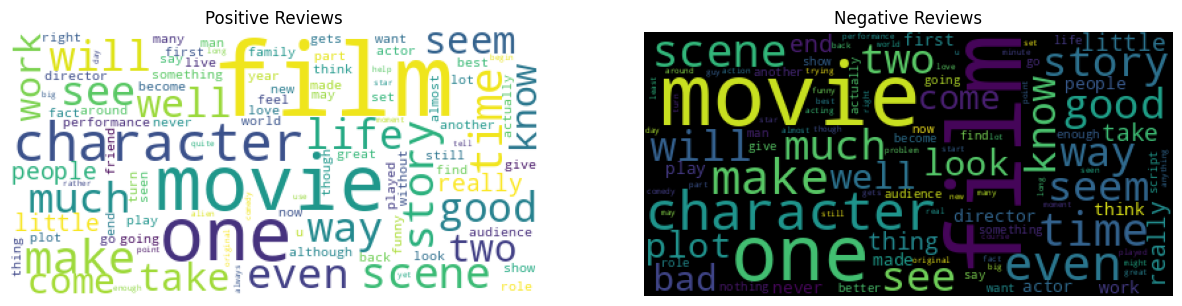

In [10]:
from wordcloud import WordCloud
import matplotlib.pyplot as plt

# Combine all positive and negative reviews
pos_reviews = ' '.join([texts[i] for i in range(len(texts)) if labels[i] == 1])
neg_reviews = ' '.join([texts[i] for i in range(len(texts)) if labels[i] == 0])

# Generate word clouds
fig, axs = plt.subplots(1, 2, figsize=(15, 7))
axs[0].imshow(WordCloud(background_color='white', max_words=100).generate(pos_reviews))
axs[0].set_title('Positive Reviews')
axs[0].axis('off')

axs[1].imshow(WordCloud(background_color='black', max_words=100).generate(neg_reviews))
axs[1].set_title('Negative Reviews')
axs[1].axis('off')

plt.show()

### Building a Sentiment Classification Pipeline

We can streamline text preprocessing and modeling using scikit-learn’s **Pipeline**.  
This allows us to chain together multiple steps — such as vectorization and classification — into a single, reusable workflow.

Here we:
- Use `TfidfVectorizer` to convert text data into numerical features.
- Apply a `LogisticRegression` classifier for sentiment prediction.
- Fit the pipeline on the training data to prepare it for evaluation.

In [11]:
from sklearn.pipeline import Pipeline
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.linear_model import LogisticRegression

# Build pipeline
pipeline = Pipeline([
    ('tfidf', TfidfVectorizer(stop_words='english')),
    ('clf', LogisticRegression(max_iter=1000))
])

# Train model
pipeline.fit(X_train, y_train)


Pipeline(steps=[('tfidf', TfidfVectorizer(stop_words='english')),
                ('clf', LogisticRegression(max_iter=1000))])

### Evaluating the Sentiment Model

Once the sentiment classifier is trained, we can assess its performance on unseen test data.  
Common evaluation metrics include:
- **Accuracy** — the percentage of correctly predicted reviews.
- **Precision, Recall, and F1-score** — provided by the classification report for a deeper look at model performance.

Here we use the trained pipeline to predict on the test set and print a detailed evaluation summary.

In [12]:
from sklearn.metrics import classification_report, confusion_matrix, accuracy_score

y_pred = pipeline.predict(X_test)

# Basic metrics
print("Accuracy:", accuracy_score(y_test, y_pred))
print("\nClassification Report:\n", classification_report(y_test, y_pred))

Accuracy: 0.805

Classification Report:
               precision    recall  f1-score   support

           0       0.77      0.84      0.80       187
           1       0.85      0.77      0.81       213

    accuracy                           0.81       400
   macro avg       0.81      0.81      0.80       400
weighted avg       0.81      0.81      0.81       400



### Visualizing Model Performance with a Confusion Matrix

A **confusion matrix** provides a clear visual summary of how well the classifier distinguishes between classes.  
It shows:
- True Positives and True Negatives (correct predictions)
- False Positives and False Negatives (misclassifications)

Here we use seaborn’s heatmap to visualize the confusion matrix for the sentiment classification model.

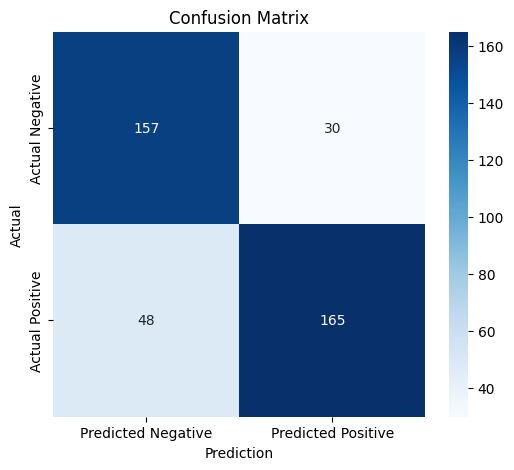

In [13]:
import seaborn as sns
import matplotlib.pyplot as plt
import numpy as np

cm = confusion_matrix(y_test, y_pred)

plt.figure(figsize=(6, 5))
sns.heatmap(cm, annot=True, fmt="d", cmap="Blues",
            xticklabels=["Predicted Negative", "Predicted Positive"],
            yticklabels=["Actual Negative", "Actual Positive"])
plt.title("Confusion Matrix")
plt.xlabel("Prediction")
plt.ylabel("Actual")
plt.show()

### Test Your Knowledge — Using Word Embeddings for Document Representation

As an alternative to TF–IDF, we can represent documents using **averaged word embeddings** from a pretrained spaCy model.  
This method captures **semantic meaning and contextual relationships** between words rather than simple frequency counts.

However, because embeddings average out sentence structure, this approach may yield **lower accuracy** for classification tasks, even though it’s semantically richer.  
It’s still a valuable experiment to understand how **semantic representations** behave in sentiment analysis.

**This may take too long to finish.**

In [ ]:
import spacy
import numpy as np
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score

nlp = spacy.load("en_core_web_md")  # Run: python -m spacy download en_core_web_md

# Average vector for each document
def get_doc_vectors(docs):
    return np.array([nlp(doc).vector for doc in docs])

X_train_embed = get_doc_vectors(X_train)
X_test_embed = get_doc_vectors(X_test)

model = LogisticRegression(max_iter=1000)
model.fit(X_train_embed, y_train)
y_pred_embed = model.predict(X_test_embed)

print("Accuracy (Embeddings):", accuracy_score(y_test, y_pred_embed))